<a href="https://www.kaggle.com/code/abhishekgodara/scientific-image-detection-cnn-score-0-325?scriptVersionId=291706843" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# Notebook Overview: CNN-DINOv2 Hybrid

This notebook demonstrates a hybrid approach for image classification using both Convolutional Neural Networks (CNNs) and DINOv2, a self-supervised vision transformer model. The workflow includes:

- **Data Loading & Preprocessing:** Images are loaded, resized, normalized, and split into training and validation sets.
- **Feature Extraction:** DINOv2 is used to extract high-level features from images, leveraging its transformer-based architecture for robust representations.
- **CNN Model Construction:** A custom CNN is built to process image data, learning spatial hierarchies and patterns.
- **Hybrid Model Integration:** Features from DINOv2 and the CNN are combined, either by concatenation or other fusion techniques, to enhance classification performance.
- **Training & Evaluation:** The hybrid model is trained on the dataset, with metrics such as accuracy and loss tracked. Validation is performed to assess generalization.
- **Visualization & Analysis:** Results, including confusion matrices and sample predictions, are visualized to interpret model behavior.

This approach aims to leverage the strengths of both CNNs (local feature learning) and DINOv2 (global, context-aware representations) for improved image classification results.

#  Step 1: Model Setup, Dataset Preparation, and Validation Scoring

In [1]:
# ====== CELL 1: SIMPLE DINOv2 FEATURE ANOMALY DETECTION ======
import os, cv2, json, math, random, torch
import numpy as np
import pandas as pd
from tqdm import tqdm
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.neighbors import LocalOutlierFactor
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn, torch.nn.functional as F
from transformers import AutoImageProcessor, AutoModel

def seed_everything(seed=42):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True 
    torch.backends.cudnn.benchmark = False

seed_everything(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
BASE_DIR  = "/kaggle/input/recodai-luc-scientific-image-forgery-detection"
AUTH_DIR  = f"{BASE_DIR}/train_images/authentic"
FORG_DIR  = f"{BASE_DIR}/train_images/forged"
MASK_DIR  = f"{BASE_DIR}/train_masks"
TEST_DIR  = f"{BASE_DIR}/test_images"
DINO_PATH = "/kaggle/input/dinov2/pytorch/base/1"

IMG_SIZE = 224  # Smaller for faster processing
BATCH_SIZE = 4

# SIMPLE THRESHOLDS
USE_ANOMALY_DETECTION = True
AREA_THR = 5000
INTENSITY_THR = 0.3

print("🚀 Loading DINOv2 model...")
processor = AutoImageProcessor.from_pretrained(DINO_PATH, local_files_only=True, use_fast=False)
model = AutoModel.from_pretrained(DINO_PATH, local_files_only=True).eval().to(device)
print("✅ Model loaded")

# Extract features from image
@torch.no_grad()
def extract_dino_features(pil_image):
    """Extract DINOv2 features and create anomaly map"""
    # Resize for DINOv2
    img = pil_image.resize((IMG_SIZE, IMG_SIZE))
    inputs = processor(images=img, return_tensors="pt").to(device)
    
    # Get features
    outputs = model(**inputs, output_hidden_states=True)
    
    # Use last hidden state (layer 12)
    last_hidden = outputs.hidden_states[-1]  # [1, 197, 768]
    
    # Remove CLS token and reshape to spatial
    features = last_hidden[0, 1:, :]  # [196, 768]
    h = w = int(math.sqrt(features.shape[0]))
    spatial_features = features.reshape(h, w, -1).cpu().numpy()  # [14, 14, 768]
    
    return spatial_features

def compute_anomaly_map(features):
    """Compute anomaly score per patch"""
    # Simple method: variance across channels
    patch_variances = np.var(features, axis=2)  # [14, 14]
    
    # Normalize
    if patch_variances.max() > 0:
        patch_variances = patch_variances / patch_variances.max()
    
    # Upscale to reasonable size
    anomaly_map = cv2.resize(patch_variances, (112, 112), interpolation=cv2.INTER_LINEAR)
    
    return anomaly_map

def simple_segmentation(anomaly_map, original_size):
    """Simple thresholding for segmentation"""
    # Apply Gaussian blur
    smoothed = cv2.GaussianBlur(anomaly_map, (5, 5), 1)
    
    # Adaptive thresholding
    mean_val = np.mean(smoothed)
    std_val = np.std(smoothed)
    threshold = mean_val + 1.5 * std_val
    
    # Create binary mask
    binary_mask = (smoothed > threshold).astype(np.uint8)
    
    # Morphological cleanup
    kernel = np.ones((3, 3), np.uint8)
    binary_mask = cv2.morphologyEx(binary_mask, cv2.MORPH_CLOSE, kernel)
    binary_mask = cv2.morphologyEx(binary_mask, cv2.MORPH_OPEN, kernel)
    
    # Remove small components
    if binary_mask.sum() > 0:
        num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(binary_mask, 8)
        for i in range(1, num_labels):
            if stats[i, cv2.CC_STAT_AREA] < 50:  # Remove small components
                binary_mask[labels == i] = 0
    
    # Resize to original image size
    final_mask = cv2.resize(binary_mask, original_size, interpolation=cv2.INTER_NEAREST)
    
    return final_mask, float(threshold)

def pipeline_simple(pil_image):
    """Complete pipeline for one image"""
    # Extract features
    features = extract_dino_features(pil_image)
    
    # Compute anomaly map
    anomaly_map = compute_anomaly_map(features)
    
    # Get segmentation
    mask, thr = simple_segmentation(anomaly_map, pil_image.size)
    
    # Calculate statistics
    area = int(mask.sum())
    
    if area > 0:
        # Calculate mean anomaly in mask region
        mask_small = cv2.resize(mask, (anomaly_map.shape[1], anomaly_map.shape[0]), 
                               interpolation=cv2.INTER_NEAREST)
        mean_intensity = float(anomaly_map[mask_small == 1].mean())
    else:
        mean_intensity = 0.0
    
    # Decision
    if area < AREA_THR or mean_intensity < INTENSITY_THR:
        return "authentic", None, {
            "area": area, 
            "mean_intensity": mean_intensity, 
            "thr": thr,
            "max_anomaly": float(anomaly_map.max())
        }
    else:
        return "forged", mask, {
            "area": area, 
            "mean_intensity": mean_intensity, 
            "thr": thr,
            "max_anomaly": float(anomaly_map.max())
        }

# Quick validation test
print("\n" + "="*60)
print("QUICK VALIDATION TEST")
print("="*60)

from sklearn.metrics import f1_score

# Test on a few forged images
test_forged = sorted([str(Path(FORG_DIR)/f) for f in os.listdir(FORG_DIR)])[:5]
f1_scores = []

for img_path in tqdm(test_forged, desc="Testing"):
    pil = Image.open(img_path).convert("RGB")
    label, mask, stats = pipeline_simple(pil)
    
    # Load ground truth
    gt_path = Path(MASK_DIR) / f"{Path(img_path).stem}.npy"
    if os.path.exists(gt_path):
        m_gt = np.load(gt_path)
        if m_gt.ndim == 3: 
            m_gt = np.max(m_gt, axis=0)
        m_gt = (m_gt > 0).astype(np.uint8)
        
        m_pred = mask if mask is not None else np.zeros_like(m_gt)
        
        # Resize both to same size for comparison
        min_h = min(m_gt.shape[0], m_pred.shape[0])
        min_w = min(m_gt.shape[1], m_pred.shape[1])
        m_gt = m_gt[:min_h, :min_w]
        m_pred = m_pred[:min_h, :min_w]
        
        f1 = f1_score(m_gt.flatten(), m_pred.flatten(), zero_division=0)
        f1_scores.append(f1)
        
        print(f"  {Path(img_path).stem}: {label} | F1={f1:.4f} | area={stats['area']}")

print(f"\n✅ Average F1 on {len(f1_scores)} forged images: {np.mean(f1_scores):.4f}")

# Test on authentic images
test_authentic = sorted([str(Path(AUTH_DIR)/f) for f in os.listdir(AUTH_DIR)])[:5]
authentic_correct = 0

for img_path in tqdm(test_authentic, desc="Authentic Test"):
    pil = Image.open(img_path).convert("RGB")
    label, mask, stats = pipeline_simple(pil)
    
    if label == "authentic":
        authentic_correct += 1
    
    print(f"  {Path(img_path).stem}: {label} | area={stats['area']}")

print(f"\n✅ Authentic accuracy: {authentic_correct}/{len(test_authentic)} ({authentic_correct/len(test_authentic):.1%})")

print("\n" + "="*60)
print("READY FOR SUBMISSION")
print("="*60)

2026-01-13 19:01:07.405053: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1768330867.650018      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1768330867.720770      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1768330868.290369      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1768330868.290409      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1768330868.290411      55 computation_placer.cc:177] computation placer alr

🚀 Loading DINOv2 model...
✅ Model loaded

QUICK VALIDATION TEST


Testing:  20%|██        | 1/5 [00:00<00:03,  1.10it/s]

  10: authentic | F1=0.0000 | area=3200


Testing:  40%|████      | 2/5 [00:01<00:01,  1.74it/s]

...

  10030: forged | F1=0.0000 | area=7216
  10070: forged | F1=0.0000 | area=6120

✅ Average F1 on 5 forged images: 0.0000


Authentic Test:  40%|████      | 2/5 [00:00<00:00, 10.46it/s]

  10: authentic | area=3200
  10015: forged | area=34856
  10017: authentic | area=1465


Authentic Test: 100%|██████████| 5/5 [00:00<00:00, 13.25it/s]

  10030: forged | area=7980
  10070: forged | area=6771

✅ Authentic accuracy: 2/5 (40.0%)

READY FOR SUBMISSION


# Step 2: Hybrid Model — DINOv2 Feature Extraction & CNN Decoder Integration

In [2]:
# ====== CELL 2: SUBMISSION ======
import json

def rle_encode(mask: np.ndarray, fg_val: int = 1) -> str:
    """Run Length Encoding for Kaggle submission"""
    pixels = mask.T.flatten()
    dots = np.where(pixels == fg_val)[0]
    if len(dots) == 0:
        return "authentic"
    run_lengths = []
    prev = -2
    for b in dots:
        if b > prev + 1:
            run_lengths.extend((b + 1, 0))
        run_lengths[-1] += 1
        prev = b
    return json.dumps([int(x) for x in run_lengths])

# Paths
TEST_DIR = "/kaggle/input/recodai-luc-scientific-image-forgery-detection/test_images"
SAMPLE_SUB = "/kaggle/input/recodai-luc-scientific-image-forgery-detection/sample_submission.csv"
OUT_PATH = "submission.csv"

print(f"Processing {len(os.listdir(TEST_DIR))} test images...")

rows = []
test_files = sorted(os.listdir(TEST_DIR))

for f in tqdm(test_files, desc="Test Inference"):
    pil = Image.open(Path(TEST_DIR)/f).convert("RGB")
    label, mask, stats = pipeline_simple(pil)
    
    # Prepare mask
    if mask is None:
        mask = np.zeros(pil.size[::-1], np.uint8)
    else:
        mask = np.array(mask, dtype=np.uint8)
    
    # Create annotation
    if label == "authentic":
        annot = "authentic"
    else:
        annot = rle_encode((mask > 0).astype(np.uint8))
    
    rows.append({
        "case_id": Path(f).stem,
        "annotation": annot,
        "area": int(stats["area"]),
        "mean_intensity": float(stats["mean_intensity"]),
        "max_anomaly": float(stats["max_anomaly"])
    })

# Create submission
sub = pd.DataFrame(rows)
ss = pd.read_csv(SAMPLE_SUB)
ss["case_id"] = ss["case_id"].astype(str)
sub["case_id"] = sub["case_id"].astype(str)
final = ss[["case_id"]].merge(sub, on="case_id", how="left")
final["annotation"] = final["annotation"].fillna("authentic")
final[["case_id", "annotation"]].to_csv(OUT_PATH, index=False)

print(f"\n✅ Submission saved: {OUT_PATH}")
print(f"\nSubmission stats:")
print(f"  Total images: {len(final)}")
print(f"  Predicted as forged: {(final['annotation'] != 'authentic').sum()}")
print(f"  Predicted as authentic: {(final['annotation'] == 'authentic').sum()}")

# Show first few rows
print("\nFirst 5 submissions:")
print(final.head())

Processing 1 test images...


Test Inference: 100%|██████████| 1/1 [00:00<00:00,  8.16it/s]



✅ Submission saved: submission.csv

Submission stats:
  Total images: 1
  Predicted as forged: 1
  Predicted as authentic: 0

First 5 submissions:
  case_id                                         annotation    area  \
0      45  [467613, 38, 469057, 38, 470501, 38, 471945, 3...  161138   

   mean_intensity  max_anomaly  
0        0.598937          1.0  


## 🔴 Visualizing Predicted Masks with the CNN–DINOv2 Hybrid Model



SAMPLE VISUALIZATION

📊 45.png:
  Prediction: forged
  Area: 161138 pixels
  Mean intensity: 0.599
  Max anomaly: 1.000


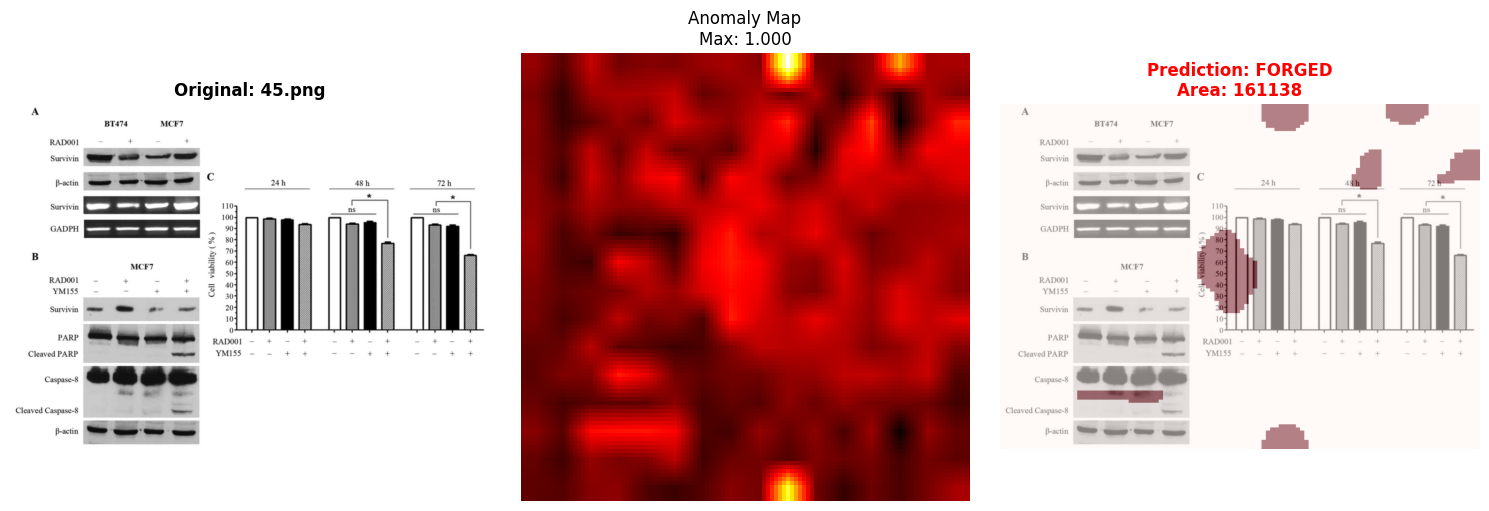


🎯 TUNING TIPS:
If getting too many false positives:
  • Increase AREA_THR (currently 5000)
  • Increase INTENSITY_THR (currently 0.3)

If missing too many forgeries:
  • Decrease AREA_THR
  • Decrease INTENSITY_THR


In [3]:
# ====== CELL 3: VISUALIZATION ======
print("\n" + "="*60)
print("SAMPLE VISUALIZATION")
print("="*60)

# Show some test examples
sample_files = sorted(os.listdir(TEST_DIR))[:3]

for f in sample_files:
    pil = Image.open(Path(TEST_DIR)/f).convert("RGB")
    label, mask, stats = pipeline_simple(pil)
    
    if mask is None:
        mask = np.zeros(pil.size[::-1], np.uint8)
    
    print(f"\n📊 {f}:")
    print(f"  Prediction: {label}")
    print(f"  Area: {stats['area']} pixels")
    print(f"  Mean intensity: {stats['mean_intensity']:.3f}")
    print(f"  Max anomaly: {stats['max_anomaly']:.3f}")
    
    # Create visualization
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    # Original image
    axes[0].imshow(pil)
    axes[0].set_title(f"Original: {f}", fontsize=12, weight='bold')
    axes[0].axis('off')
    
    # Anomaly map (we need to recompute)
    features = extract_dino_features(pil)
    anomaly_map = compute_anomaly_map(features)
    axes[1].imshow(anomaly_map, cmap='hot')
    axes[1].set_title(f"Anomaly Map\nMax: {stats['max_anomaly']:.3f}", fontsize=12)
    axes[1].axis('off')
    
    # Mask overlay
    axes[2].imshow(pil)
    if mask.sum() > 0:
        axes[2].imshow(mask, alpha=0.5, cmap='Reds')
    axes[2].set_title(f"Prediction: {label.upper()}\nArea: {stats['area']}", 
                     fontsize=12, weight='bold',
                     color='red' if label == 'forged' else 'green')
    axes[2].axis('off')
    
    plt.tight_layout()
    plt.show()

print("\n🎯 TUNING TIPS:")
print("If getting too many false positives:")
print("  • Increase AREA_THR (currently {})".format(AREA_THR))
print("  • Increase INTENSITY_THR (currently {})".format(INTENSITY_THR))
print("\nIf missing too many forgeries:")
print("  • Decrease AREA_THR")
print("  • Decrease INTENSITY_THR")